# Análise e Transformação

Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.tsa.stattools
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

Carregando Dados

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Projeto Arima - series temporais /df_chuvas_treated', sep=',')

In [4]:
df.head(40)

,Ano,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro
0,1985,184.90,242.9,230.00,59.0,126.2,14.60,4.0,21.80,126.1,71.10,111.30,155.20
1,1986,199.60,221.0,218.70,106.5,113.1,3.90,30.3,27.85,34.5,60.70,242.50,389.90
2,1987,525.80,249.3,161.30,98.1,293.8,183.90,11.8,30.90,80.2,84.80,72.70,152.10
3,1988,268.70,224.4,189.20,175.1,224.9,58.60,1.3,0.20,28.4,173.90,100.20,289.80
4,1989,312.90,344.3,288.20,66.3,21.7,52.50,150.1,32.90,52.1,80.10,88.00,236.70
5,1990,284.10,196.9,310.10,85.8,77.9,50.60,121.2,76.30,97.2,206.80,116.30,149.80
6,1991,330.70,340.3,522.40,200.3,43.3,96.80,28.2,37.30,101.4,168.00,67.30,237.90
7,1992,129.20,258.5,227.97,87.2,93.5,11.60,40.9,24.70,150.6,219.60,145.04,211.70
8,1993,221.50,225.7,110.00,84.6,133.9,74.70,11.2,40.80,210.1,134.10,125.50,170.50
9,1994,196.90,184.4,231.60,111.4,54.9,30.50,39.2,2.40,1.8,147.60,86.60,276.30


Transformação do df formato wide para long

In [5]:
df_chuva01 = df.drop(columns='Ano')

In [6]:
#tranformação para array
df_chuva02 = df_chuva01.values
df_chuva02

array([[1.8490e+02, 2.4290e+02, 2.3000e+02, 5.9000e+01, 1.2620e+02,
        1.4600e+01, 4.0000e+00, 2.1800e+01, 1.2610e+02, 7.1100e+01,
        1.1130e+02, 1.5520e+02],
       [1.9960e+02, 2.2100e+02, 2.1870e+02, 1.0650e+02, 1.1310e+02,
        3.9000e+00, 3.0300e+01, 2.7850e+01, 3.4500e+01, 6.0700e+01,
        2.4250e+02, 3.8990e+02],
       [5.2580e+02, 2.4930e+02, 1.6130e+02, 9.8100e+01, 2.9380e+02,
        1.8390e+02, 1.1800e+01, 3.0900e+01, 8.0200e+01, 8.4800e+01,
        7.2700e+01, 1.5210e+02],
       [2.6870e+02, 2.2440e+02, 1.8920e+02, 1.7510e+02, 2.2490e+02,
        5.8600e+01, 1.3000e+00, 2.0000e-01, 2.8400e+01, 1.7390e+02,
        1.0020e+02, 2.8980e+02],
       [3.1290e+02, 3.4430e+02, 2.8820e+02, 6.6300e+01, 2.1700e+01,
        5.2500e+01, 1.5010e+02, 3.2900e+01, 5.2100e+01, 8.0100e+01,
        8.8000e+01, 2.3670e+02],
       [2.8410e+02, 1.9690e+02, 3.1010e+02, 8.5800e+01, 7.7900e+01,
        5.0600e+01, 1.2120e+02, 7.6300e+01, 9.7200e+01, 2.0680e+02,
        1.1630e+02,

In [7]:
#tranformação do array para list usando o método flatten
df_chuva03 = list(df_chuva02.flatten())
df_chuva03

[np.float64(184.9),
 np.float64(242.9),
 np.float64(230.0),
 np.float64(59.0),
 np.float64(126.2),
 np.float64(14.6),
 np.float64(4.0),
 np.float64(21.8),
 np.float64(126.1),
 np.float64(71.1),
 np.float64(111.3),
 np.float64(155.2),
 np.float64(199.6),
 np.float64(221.0),
 np.float64(218.7),
 np.float64(106.5),
 np.float64(113.1),
 np.float64(3.9),
 np.float64(30.3),
 np.float64(27.85),
 np.float64(34.5),
 np.float64(60.7),
 np.float64(242.5),
 np.float64(389.9),
 np.float64(525.8),
 np.float64(249.3),
 np.float64(161.3),
 np.float64(98.1),
 np.float64(293.8),
 np.float64(183.9),
 np.float64(11.8),
 np.float64(30.9),
 np.float64(80.2),
 np.float64(84.8),
 np.float64(72.7),
 np.float64(152.1),
 np.float64(268.7),
 np.float64(224.4),
 np.float64(189.2),
 np.float64(175.1),
 np.float64(224.9),
 np.float64(58.6),
 np.float64(1.3),
 np.float64(0.2),
 np.float64(28.4),
 np.float64(173.9),
 np.float64(100.2),
 np.float64(289.8),
 np.float64(312.9),
 np.float64(344.3),
 np.float64(288.2),
 np

In [8]:
indice = pd.date_range('1985', periods= len(df_chuva03), freq='M')
indice

/tmp/ipython-input-3595497089.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  indice = pd.date_range('1985', periods= len(df_chuva03), freq='M')


DatetimeIndex(['1985-01-31', '1985-02-28', '1985-03-31', '1985-04-30',
               '1985-05-31', '1985-06-30', '1985-07-31', '1985-08-31',
               '1985-09-30', '1985-10-31',
               ...
               '2020-03-31', '2020-04-30', '2020-05-31', '2020-06-30',
               '2020-07-31', '2020-08-31', '2020-09-30', '2020-10-31',
               '2020-11-30', '2020-12-31'],
              dtype='datetime64[ns]', length=432, freq='ME')

In [9]:
serie_chuva = pd.Series(data=df_chuva03, index= indice)
serie_chuva

,0
1985-01-31,184.90
1985-02-28,242.90
1985-03-31,230.00
1985-04-30,59.00
1985-05-31,126.20
...,...
2020-08-31,62.10
2020-09-30,22.90
2020-10-31,213.90
2020-11-30,162.10


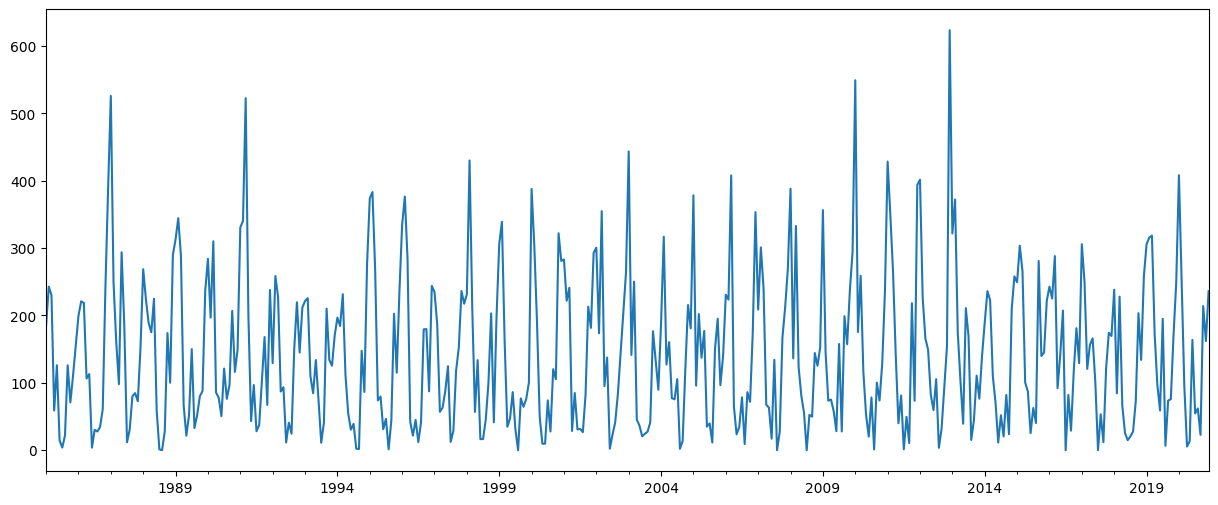

In [10]:
serie_chuva.plot()
plt.show()

In [11]:
# Guardar a serie_chuva num ficheiro CSV
serie_chuva.to_csv('serie_chuva_processada.csv', index=True)

# Análise Estatística

In [12]:
media_movel = serie_chuva.rolling (window=6)
media_movel = media_movel.mean()

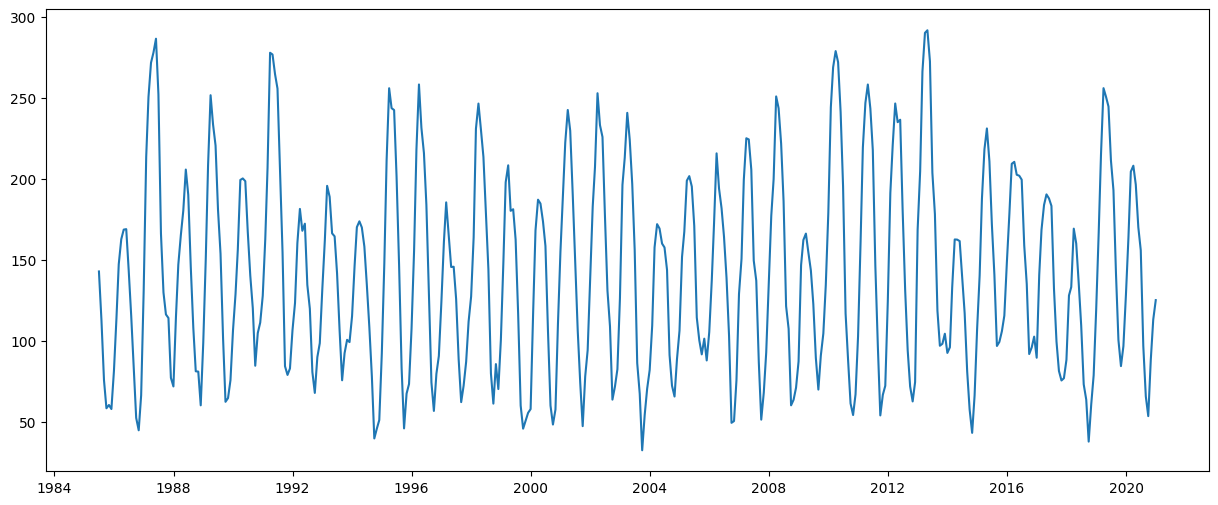

In [13]:
plt.plot(media_movel)

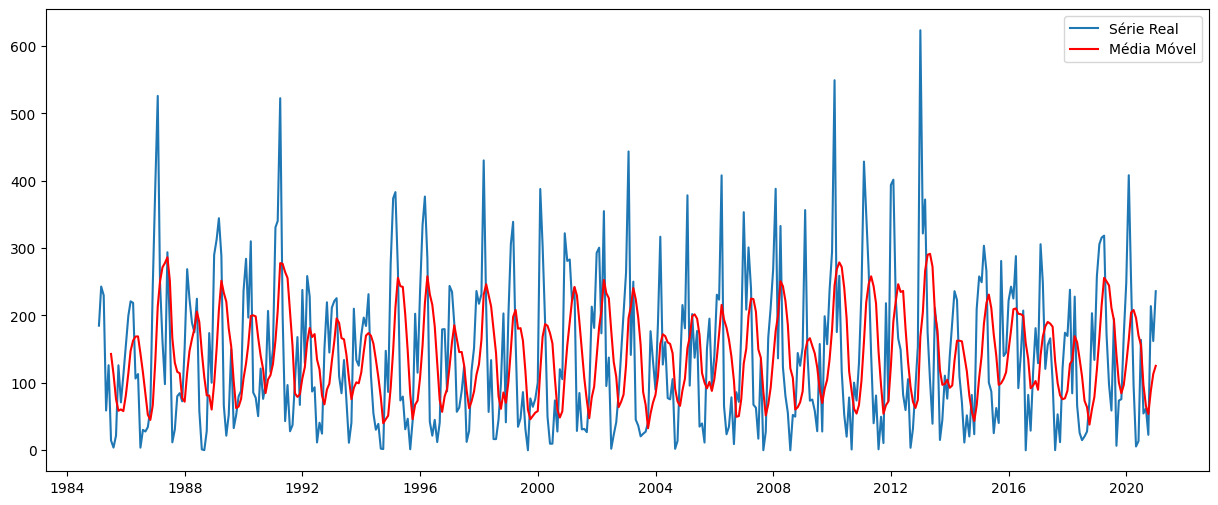

In [14]:
plt.plot(serie_chuva, label= 'Série Real')
plt.plot(media_movel, color= 'red', label= 'Média Móvel')
plt.legend(loc = 'best')
plt.show()

# Decomposição

In [15]:
decomposicao = seasonal_decompose(serie_chuva)

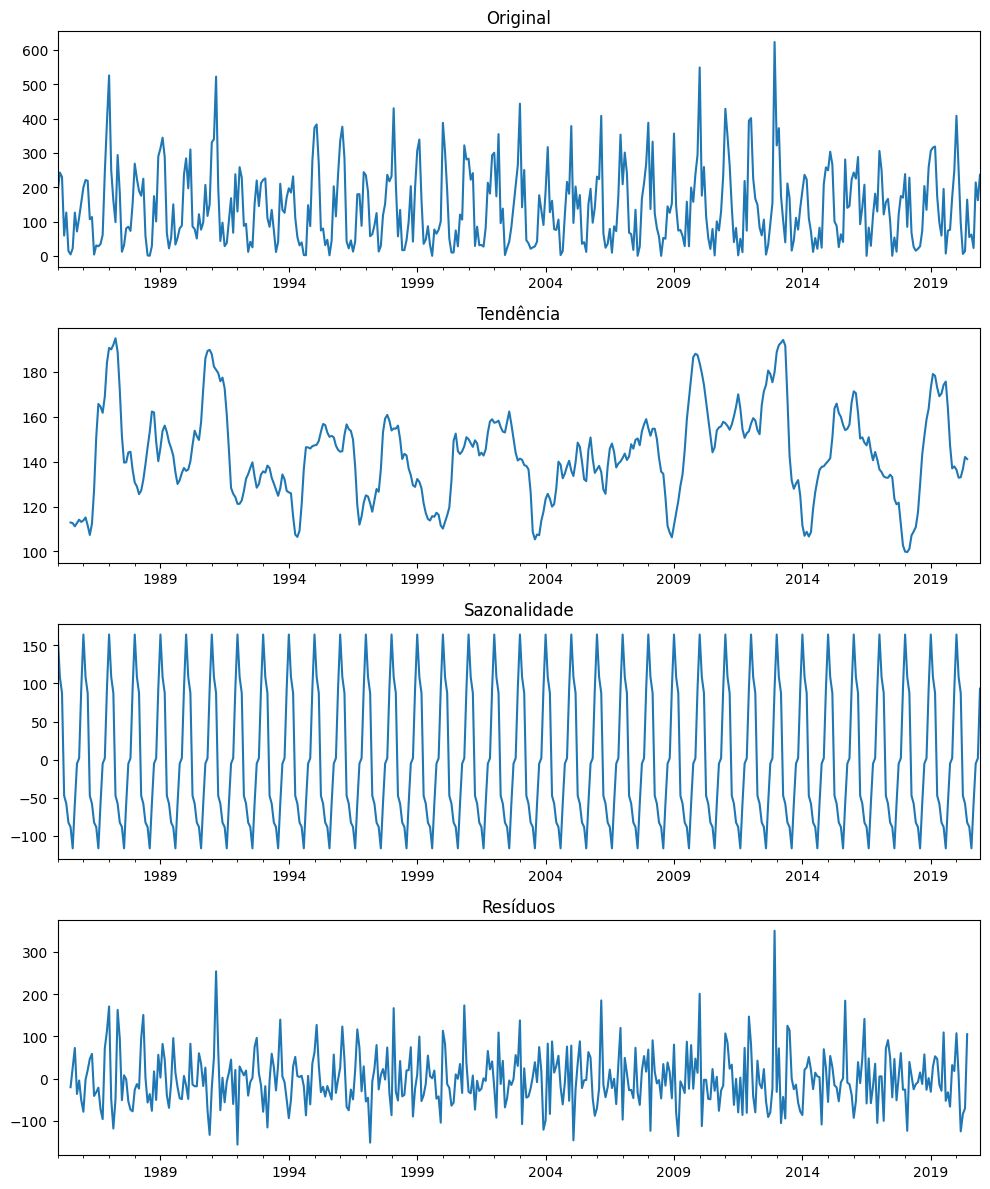

In [16]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10,12))

decomposicao.observed.plot(ax=ax1, title='Original')
decomposicao.trend.plot(ax=ax2, title='Tendência')
decomposicao.seasonal.plot(ax=ax3, title='Sazonalidade')
decomposicao.resid.plot(ax=ax4, title='Resíduos', style='-')

plt.tight_layout()
plt.show()

- Tendencia, ausência de yendencia crescente ou descrescente
- Sazonalidade constante com intervalos bem definidos
- Residuos,

# Verificação da Normalidade

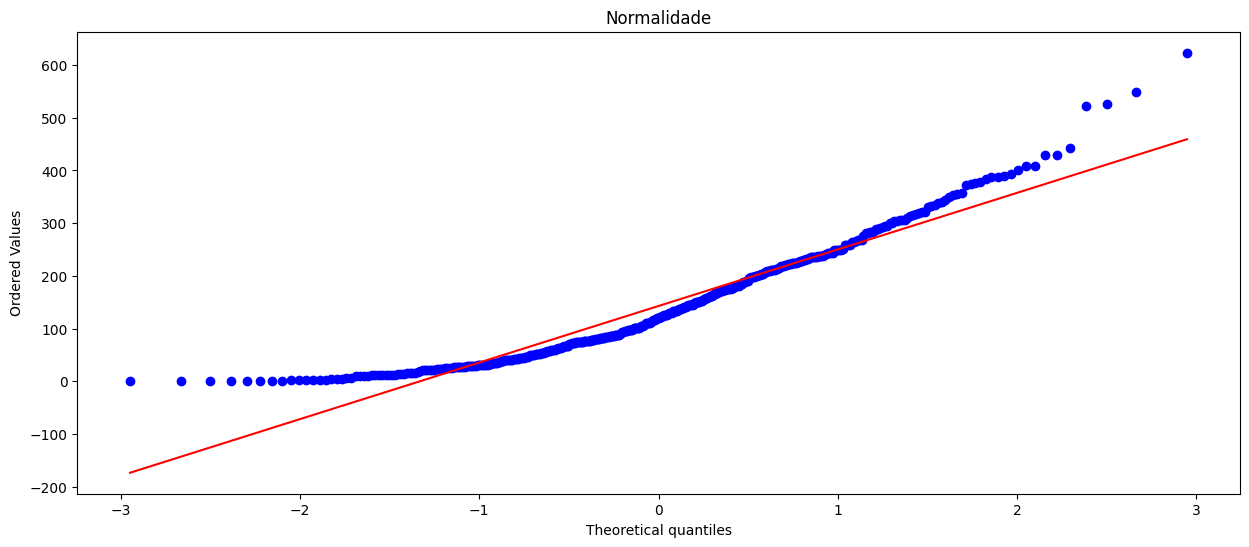

In [17]:
stats.probplot(serie_chuva, dist='norm', plot = plt)
plt.title('Normalidade')
plt.show()

<Axes: ylabel='Count'>

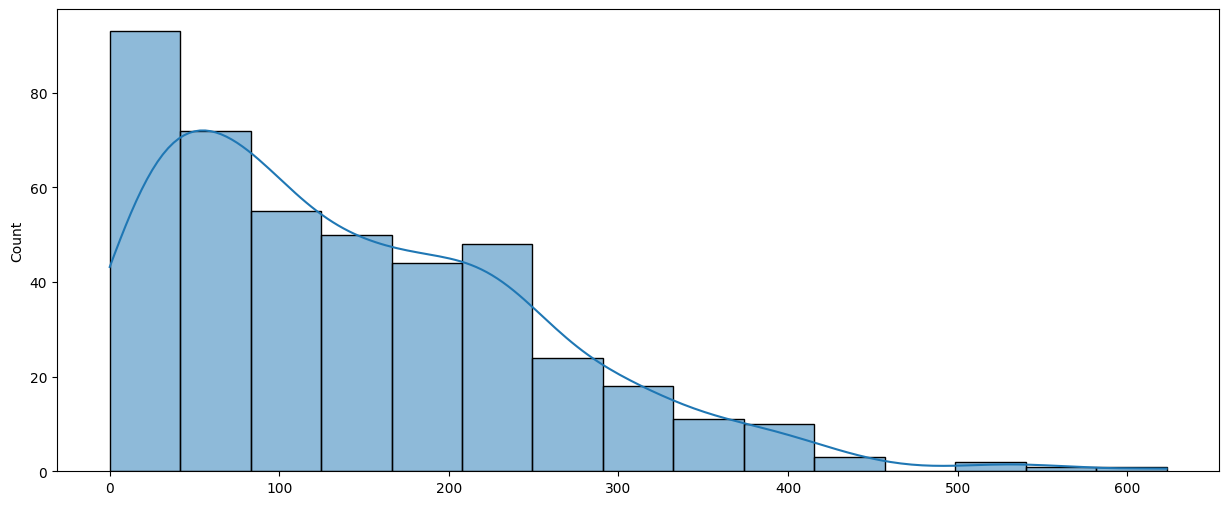

In [18]:
sns.histplot(serie_chuva, kde= True)


Dsitribuição não normal

Teste de Shapiro- Wilk para evidenciar a distribuição anormal.

Significância: 0,05(5%)
* Ho = dis.normal p>0,05
* Ha = dis.não normal p<=-0,05

In [19]:
e, p = stats.shapiro(serie_chuva)
print( f"Estatística de teste: {e}")
print(f"p-valor: {p}")

Estatística de teste: 0.9260316422606948
p-valor: 9.10739665543704e-14


# Tranformação (Log)


In [20]:
serie_log_chuva = np.log(serie_chuva)
serie_log_chuva

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,0
1985-01-31,5.219815
1985-02-28,5.492650
1985-03-31,5.438079
1985-04-30,4.077537
1985-05-31,4.837868
...,...
2020-08-31,4.128746
2020-09-30,3.131137
2020-10-31,5.365509
2020-11-30,5.088213


In [21]:
e , p = stats.shapiro(serie_log_chuva)
print( f"Estatística de teste: {e}")
print(f"p-valor: {p}")

Estatística de teste: nan
p-valor: 1.0


A transformação usando log não é recomendada quando temos valores 0 e/ou negativos

# Transformação usando a raiz cúbica (uma vez que possuimos valor 0 ou negativo)

In [22]:
serie_raiz3_chuva = (serie_chuva)**(1/3)
serie_raiz3_chuva

,0
1985-01-31,5.696992
1985-02-28,6.239395
1985-03-31,6.126926
1985-04-30,3.892996
1985-05-31,5.015949
...,...
2020-08-31,3.960018
2020-09-30,2.839739
2020-10-31,5.980492
2020-11-30,5.452483


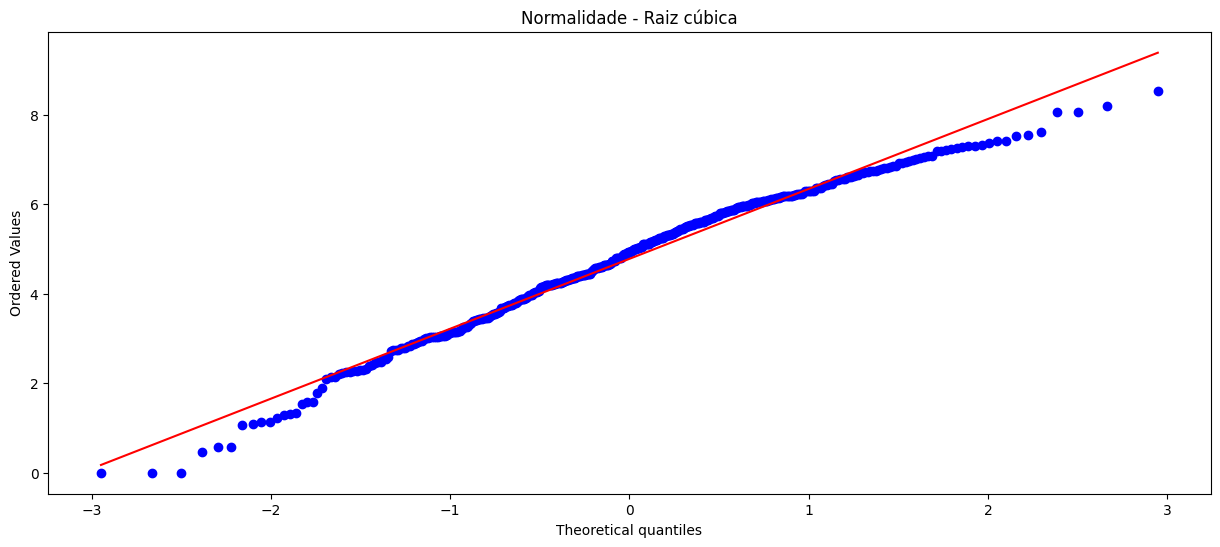

In [23]:
stats.probplot(serie_raiz3_chuva, dist='norm', plot= plt)
plt.title('Normalidade - Raiz cúbica')
plt.show()

In [24]:
e, p= stats.shapiro(serie_raiz3_chuva)
print( f"Estatística de teste: {e}")
print(f"p-valor: {p}")

Estatística de teste: 0.9826487042592641
p-valor: 4.832151649260338e-05


<Axes: ylabel='Count'>

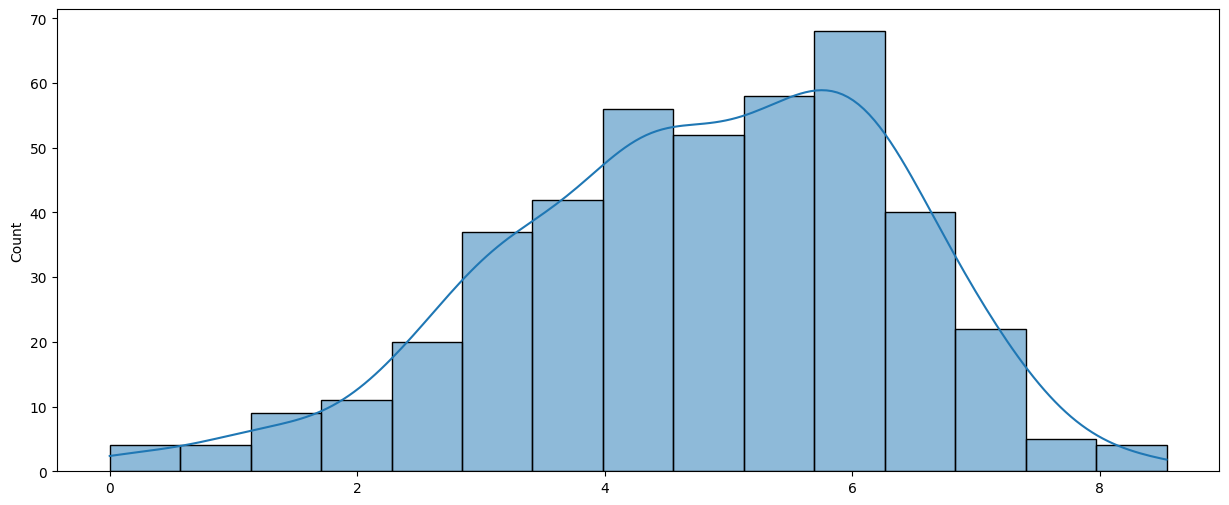

In [25]:
sns.histplot(serie_raiz3_chuva, kde=True)

Série inicial para comparação

<Axes: ylabel='Count'>

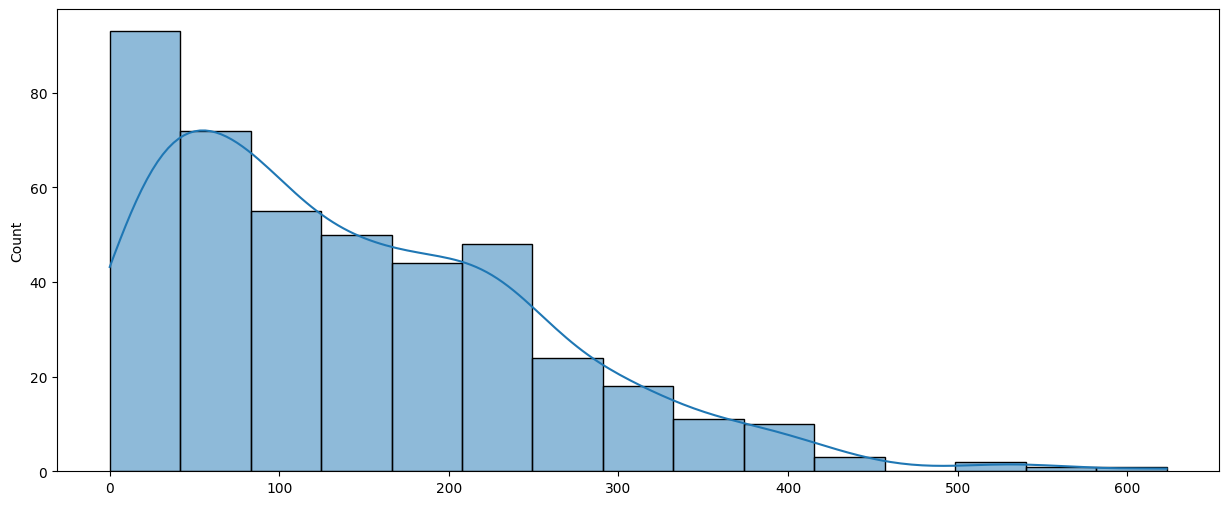

In [26]:
sns.histplot(serie_chuva, kde= True)

Observa-se que após tranformação usando a raiz cúbica houve uma melhora siginifcativa(4.832151649260338e-05) em relação a serie sem tranformação(9.10739665543704e-14), ainda assim o perfíl dos valores é caracterizado como não normal


# Verificação de Estacionaridade

Teste KPSS
*   Ha = Não estacionário: estatística do teste > valor crítico
*   Ho = É estacionário: estatística do teste < valor crítico



In [27]:
kpss = statsmodels.tsa.stattools.kpss(serie_raiz3_chuva)
print( f"Estatística do teste: {kpss[0]}")
print( f"p_valor: {kpss[1]}")
print( f"Valores Críticos: ")
for chave, valor in kpss[3].items():
  print( f"{chave} {valor}")

Estatística do teste: 0.019943658616702168
p_valor: 0.1
Valores Críticos: 
10% 0.347
5% 0.463
2.5% 0.574
1% 0.739


/tmp/ipython-input-4237417755.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss = statsmodels.tsa.stattools.kpss(serie_raiz3_chuva)


A estatística do teste(0.0199) é menor que o valor crítico (0.463), logo, podemos afirmar que é estacionário.

Não há uma tendência forte: A chuva não está a aumentar nem a diminuir de forma persistente ao longo dos anos; ela flutua em torno de uma média constante.

O terreno é firme: Podes avançar para os modelos de previsão (como o ARIMA) sem teres de fazer transformações matemáticas complexas para "endireitar" os dados.

# Verificação da Autocorrelação

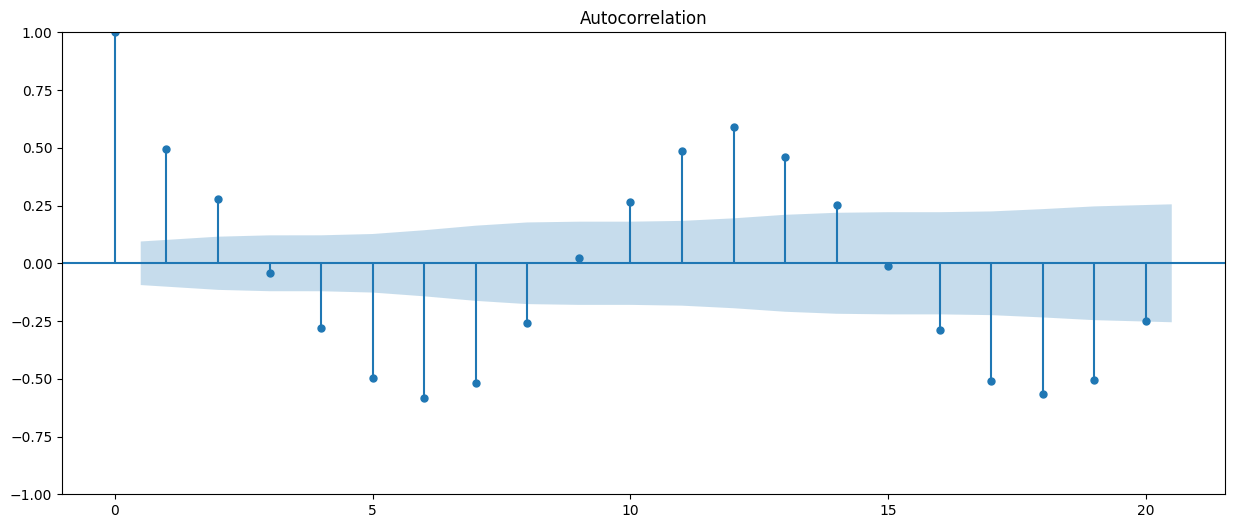

In [28]:
plot_acf(serie_raiz3_chuva, lags=20)
plt.show()

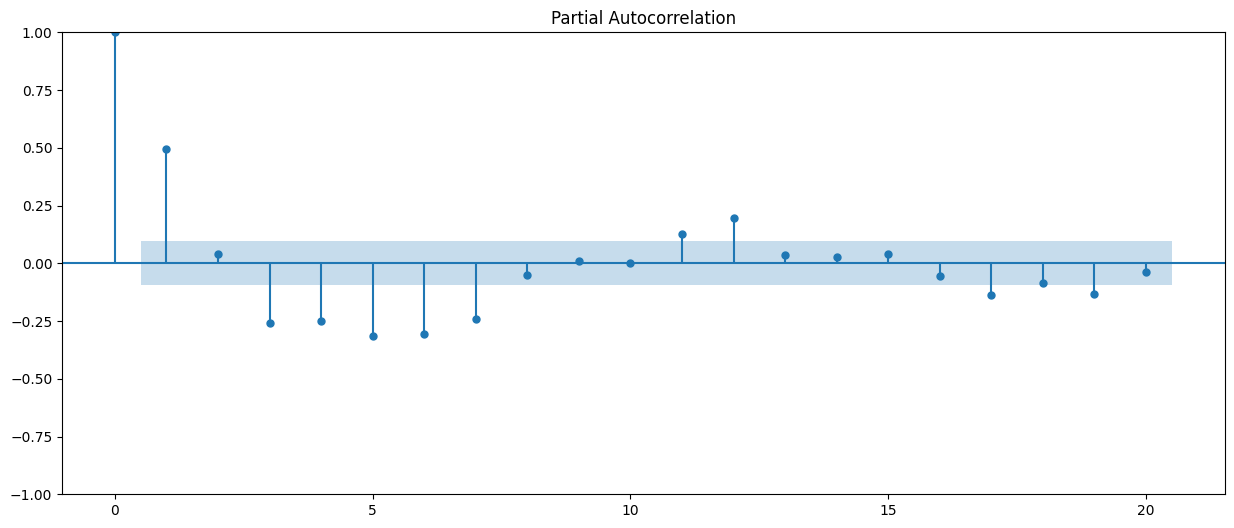

In [29]:
plot_pacf(serie_raiz3_chuva, lags=20)
plt.show()